# Individual variation

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import io
import itertools
import os
import subprocess
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import msprime
import numpy as np
import pandas as pd
import polars as pl
import scipy.stats
import seaborn as sns
import statsmodels.stats.proportion
import tqdm

pd.set_option("display.max_rows", 1000)
plt.rcParams["pdf.use14corefonts"] = True
pl.Config.set_tbl_rows(-1)
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [3]:
repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
elif not (repo / "notebooks").exists():
    repo = Path("/nfs/users/nfs_r/rs42/rs42/git/recombination")

sys.path.insert(0, str(repo))
from src.IDs import *

figure_dir = repo / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

In [4]:
grch37_chromosome_sizes_in_bp = {
    "chr1": 249250621,
    "chr2": 243199373,
    "chr3": 198022430,
    "chr4": 191154276,
    "chr5": 180915260,
    "chr6": 171115067,
    "chr7": 159138663,
    "chr8": 146364022,
    "chr9": 141213431,
    "chr10": 135534747,
    "chr11": 135006516,
    "chr12": 133851895,
    "chr13": 115169878,
    "chr14": 107349540,
    "chr15": 102531392,
    "chr16": 90354753,
    "chr17": 81195210,
    "chr18": 78077248,
    "chr19": 59128983,
    "chr20": 63025520,
    "chr21": 48129895,
    "chr22": 51304566,
}

genetic_map_dir = Path("/lustre/scratch122/tol/projects/sperm/data/references/04.genetic_maps/01.Bherer_etal_SexualDimorphismRecombination/Refined_EUR_genetic_map_b37")

rate_maps = {}
for chrom in aut_chrom_names:
    rate_maps[chrom] = msprime.RateMap.read_hapmap(
        open(genetic_map_dir / f"male_{chrom}.txt"),
        sequence_length=grch37_chromosome_sizes_in_bp[chrom],
    )

## Helpers

In [5]:
def permutation_testing(pairs, n_perms=10, seed=42, method="AD"):
    with warnings.catch_warnings(action="ignore"):
        if method == "KS":
            test_statistic = lambda x, y: scipy.stats.ks_2samp(x, y, method="auto").statistic
        if method == "AD":
            test_statistic = lambda x, y: scipy.stats.anderson_ksamp([x, y]).statistic
        if method == "U":
            test_statistic = lambda x, y: scipy.stats.mannwhitneyu(x, y, use_continuity=False).statistic

        rng = np.random.default_rng(seed=seed)
        orig = np.sum([test_statistic(x, y) for x, y in pairs if len(x) > 2 and len(y) > 2])
        permuted = []
        for i in range(n_perms):
            sum_stats = 0
            for x, y in pairs:
                if len(x) > 2 and len(y) > 2:
                    z = np.concatenate([x, y])
                    px, py = np.split(rng.permutation(z), [len(x)])
                    sum_stats += test_statistic(px, py)
            permuted.append(sum_stats)

        return np.mean(np.array(permuted) >= orig)

In [6]:
def get_sample_pairwise_tests(sample_ids, test_df, test_field, n_perms=1000, take_log10=False):
    sample_id_to_signal = {}
    for sample_id in sample_ids:
        sdf = test_df.filter(pl.col("sample_id") == sample_id)
        signal = sdf[test_field].to_numpy()
        if take_log10:
            signal = np.log10(signal)
        sample_id_to_signal[sample_id] = signal

    rows = []
    for sample_id1, sample_id2 in tqdm.tqdm(list(itertools.combinations(sorted(sample_ids), 2))):
        signal_1 = sample_id_to_signal[sample_id1]
        signal_2 = sample_id_to_signal[sample_id2]
        rows.append([
            sample_id1,
            sample_id2,
            sample_id_to_paper_label[sample_id1],
            sample_id_to_paper_label[sample_id2],
            len(signal_1),
            len(signal_2),
            scipy.stats.ks_2samp(signal_1, signal_2).pvalue,
            permutation_testing([[signal_1, signal_2]], n_perms),
        ])

    return pl.DataFrame(
        rows,
        schema=["sample_id1", "sample_id2", "paper_label_id1", "paper_label_id2", "n1", "n2", "ks_pvalue", "AD_perm_pvalue"],
        orient="row",
    )

def get_sample_vs_rest_tests(sample_ids, test_df, test_field, n_perms=1000):
    sample_id_to_signal = {}
    for sample_id in sample_ids:
        sdf = test_df.filter(pl.col("sample_id") == sample_id)
        sample_id_to_signal[sample_id] = sdf[test_field].to_numpy()

    def runme(sample_id):
        lens_1 = sample_id_to_signal[sample_id]
        pairs = [[lens_1, sample_id_to_signal[other_sample_id]] for other_sample_id in sample_ids if other_sample_id != sample_id]
        p_separate = permutation_testing(pairs, n_perms)
        rest = np.concatenate([sample_id_to_signal[other_sample_id] for other_sample_id in sample_ids if other_sample_id != sample_id])
        p_agg = permutation_testing([[lens_1, rest]], n_perms)
        p_ttest = scipy.stats.ttest_ind(lens_1, rest).pvalue
        return (sample_id, sample_id_to_paper_label[sample_id], len(lens_1), p_separate, p_agg, p_ttest)

    rows = joblib.Parallel(n_jobs=-1, verbose=10)(joblib.delayed(runme)(sample_id) for sample_id in sorted(sample_ids))
    return pl.DataFrame(
        rows,
        schema=["sample_id", "paper_label_id", "n_in_sample", "AD_perm_pvalue", "AD_perm_pvalue_agg", "ttest_pvalue_agg"],
        orient="row",
    ).sort("AD_perm_pvalue")

In [7]:
def plot_boxplots_samples(test_df, test_column, xlabel="", take_log10=True, ticks=None, figsize=(6, 7), label_to_color=None, ax=None, show_labels=True, default_color="#f7f7f7"):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    D = {}
    for sample_id in sample_ids:
        signal = test_df.filter(pl.col("sample_id") == sample_id)[test_column].to_numpy()
        if take_log10:
            signal = np.log10(signal)
        D[sample_id] = signal

    color_palette = None
    if label_to_color is not None:
        color_palette = [label_to_color.get(sample_id_to_paper_label[sample_id], default_color) for sample_id in sample_id_order]

    sns.boxplot(
        data=[D[k] for k in sample_id_order],
        orient="h",
        ax=ax,
        showfliers=False,
        showmeans=True,
        palette=color_palette,
        medianprops=dict(linewidth=0.5, color="black"),
        meanprops=dict(marker=".", markeredgecolor="black", markerfacecolor="black", markersize=10),
        whis=(10, 90),
    )

    if ticks is not None:
        if take_log10:
            ax.set_xticks(ticks=ticks, labels=[f"$10^{{{x}}}$" for x in ticks])
        else:
            ax.set_xticks(ticks=ticks, labels=[str(x) for x in ticks])

    ax.set_xlabel(xlabel)
    sns.despine(ax=ax, top=True, right=True, left=True, bottom=False)

    if show_labels:
        ax.set_yticks(np.arange(len(sample_id_order)), [sample_id_to_paper_label[k] for k in sample_id_order])
    else:
        ax.set_yticks([], [])

    return ax

def plot_dsb_fraction(sample_id_to_AA_heats, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))

    mns = [(sample_id_to_AA_heats[s] > 0).mean() for s in sample_id_order]
    cis = [
        statsmodels.stats.proportion.proportion_confint(
            (sample_id_to_AA_heats[s] > 0).sum(),
            len(sample_id_to_AA_heats[s]),
            method="beta",
        )
        for s in sample_id_order
    ]

    ax.errorbar(
        x=mns,
        y=np.arange(len(sample_id_order)),
        xerr=[
            [mn - low_ci for ((low_ci, high_ci), mn) in zip(cis, mns)],
            [high_ci - mn for ((low_ci, high_ci), mn) in zip(cis, mns)],
        ],
        fmt=".-",
        ms=10,
    )
    ax.set_yticks(np.arange(len(sample_id_order)), [sample_id_to_paper_label[x] for x in sample_id_order])
    ax.set_xlabel("Fraction of reads")
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax, top=True, right=True)
    return ax

In [8]:
def plot_cm_diffs(df, label_list1, label_list2, label_legend1="", label_legend2="", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    sample_ids1 = [k for k, v in sample_id_to_paper_label.items() if v in label_list1]
    sample_ids2 = [k for k, v in sample_id_to_paper_label.items() if v in label_list2]

    if label_legend1 == "":
        label_legend1 = ", ".join(sample_ids1)
    if label_legend2 == "":
        label_legend2 = ", ".join(sample_ids2)

    x1 = pd.Series(np.log10(df.filter(pl.col("sample_id").is_in(sample_ids1))["CO_active_interval_crossover_prob"] * 1e2), name=label_legend1)
    x2 = pd.Series(np.log10(df.filter(pl.col("sample_id").is_in(sample_ids2))["CO_active_interval_crossover_prob"] * 1e2), name=label_legend2)

    sns.histplot(
        data=[x1, x2],
        bins=25,
        multiple="dodge",
        shrink=0.8,
        stat="proportion",
        common_norm=False,
        ax=ax,
    )
    sns.despine(ax=ax)
    ax.set_xlabel("Genetic length (cM)")
    ax.set_xticks(ticks=np.arange(-7, 1), labels=[f"$10^{{{x}}}$" for x in np.arange(-7, 1)])


def test_fishers_exact_one_vs_rest(sample_ids, sample_id_to_AA_heats):
    rows = []
    for sample_id in tqdm.tqdm(sample_ids):
        xx = sample_id_to_AA_heats[sample_id]
        sx = (xx > 0).sum()
        yy = np.concatenate([sample_id_to_AA_heats[s] for s in sample_ids if s != sample_id])
        sy = (yy > 0).sum()
        pval = scipy.stats.fisher_exact([[sx, len(xx) - sx], [sy, len(yy) - sy]]).pvalue
        rows.append([sample_id, sample_id_to_paper_label[sample_id], sx / len(xx), sy / len(yy), pval])
    return pl.DataFrame(rows, schema=["sample_id", "paper_label", "prop", "other_prop", "fisher_pval"], orient="row").sort("fisher_pval")


def pairwise_fisher(sample_id1, sample_id2, sample_id_to_AA_heats):
    x = sample_id_to_AA_heats[sample_id1]
    y = sample_id_to_AA_heats[sample_id2]
    return scipy.stats.fisher_exact([[(x > 0).sum(), (x == 0).sum()], [(y > 0).sum(), (y == 0).sum()]]).pvalue

## Events

In [9]:
rahbari_df = pl.read_csv(repo / "configs" / "Rahbari.tsv", separator="\t")
sudmant_df = (
    pl.read_csv(repo / "configs" / "Sudmant.tsv", separator="\t")
    .with_columns(
        pl.col("sample_set").cast(pl.String),
        pl.col("sample_id").cast(pl.String),
    )
)

rahbari_output = Path("/lustre/scratch122/tol/projects/sperm/results/Rahbari_20250212")
sudmant_output = Path("/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121")

read_fields = [
    "read_name",
    "read_length",
    "chrom",
    "sample_id",
    "high_quality_snp_positions",
    "CO_active_interval_crossover_prob",
    "full_read_crossover_prob",
    "grch37_reference_start",
    "grch38_reference_start",
    "grch37_reference_end",
    "grch38_reference_end",
    "AA_motif_center_pos",
    "AA_heat",
    "AA_motif_strand",
    "is_high_quality_read",
    "is_contamination",
    "high_quality_classification_class",
    "snp_positions_on_read",
    "idx_transitions",
    "high_quality_classification_in_detectable_class",
    "total_mismatches",
]

def read_paths(config_df, output_path):
    for sample_id, sample_set in config_df.select("sample_id", "sample_set").unique().iter_rows():
        for chrom in aut_chrom_names:
            yield output_path / "read_analysis" / sample_set / sample_id / "reads" / chrom / "all_reads_structure_annotated.parquet"

def scan_cos(config_df, output_path):
    return pl.concat([
        pl.scan_parquet(str(filename))
        .select(read_fields)
        .filter(pl.col("high_quality_classification_in_detectable_class") == "CO")
        .filter(pl.col("high_quality_snp_positions").list.len() >= 4)
        .filter(pl.col("is_high_quality_read"))
        .filter(pl.col("CO_active_interval_crossover_prob") > 0)
        for filename in read_paths(config_df, output_path)
    ])

def scan_ncos(config_df, output_path):
    return pl.concat([
        pl.scan_parquet(str(filename))
        .select(read_fields)
        .filter(pl.col("high_quality_snp_positions").list.len() >= 3)
        .filter(pl.col("high_quality_classification_class") == "GC")
        .filter(pl.col("is_high_quality_read"))
        .filter(~pl.col("is_contamination"))
        .filter(pl.col("CO_active_interval_crossover_prob") > 0)
        for filename in read_paths(config_df, output_path)
    ])

CO_df = (
    pl.concat([
        scan_cos(rahbari_df, rahbari_output),
        scan_cos(sudmant_df, sudmant_output),
    ])
    .collect()
)

NCO_df = (
    pl.concat([
        scan_ncos(rahbari_df, rahbari_output),
        scan_ncos(sudmant_df, sudmant_output),
    ])
    .collect()
)

In [10]:
def add_recombination_fields(df):
    df = (
        df
        .with_columns(
            grch37_recombining_interval_start_pos=pl.col("grch37_reference_start") + pl.col("snp_positions_on_read").list.get(pl.col("idx_transitions").list.get(0)),
            grch37_recombining_interval_end_pos=pl.col("grch37_reference_start") + pl.col("snp_positions_on_read").list.get(pl.col("idx_transitions").list.get(-1) + 1),
            grch38_recombining_interval_start_pos=pl.col("grch38_reference_start") + pl.col("snp_positions_on_read").list.get(pl.col("idx_transitions").list.get(0)),
            grch38_recombining_interval_end_pos=pl.col("grch38_reference_start") + pl.col("snp_positions_on_read").list.get(pl.col("idx_transitions").list.get(-1) + 1),
            grch37_first_converted_marker_pos=pl.col("grch37_reference_start") + pl.col("snp_positions_on_read").list.get(pl.col("idx_transitions").list.get(0) + 1),
        )
        .with_columns(
            grch37_recombining_interval_length=pl.col("grch37_recombining_interval_end_pos") - pl.col("grch37_recombining_interval_start_pos"),
            grch38_recombining_interval_length=pl.col("grch38_recombining_interval_end_pos") - pl.col("grch38_recombining_interval_start_pos"),
        )
    )

    dfs = []
    for [chrom], chrom_df in df.partition_by(by=["chrom"], as_dict=True).items():
        rate_map = rate_maps[chrom]
        dfs.append(
            chrom_df.with_columns(
                grch37_recombining_interval_start_poses_cm=rate_map.get_cumulative_mass(chrom_df["grch37_recombining_interval_start_pos"]) * 1e2,
                grch37_recombining_interval_end_poses_cm=rate_map.get_cumulative_mass(chrom_df["grch37_recombining_interval_end_pos"]) * 1e2,
                grch37_first_converted_marker_poses_rate=rate_map.get_rate(chrom_df["grch37_first_converted_marker_pos"]) * 1e2,
            ).with_columns(
                grch37_recombining_interval_cM=pl.col("grch37_recombining_interval_end_poses_cm") - pl.col("grch37_recombining_interval_start_poses_cm"),
                grch37_cM_per_bp_across_recombining_interval=(pl.col("grch37_recombining_interval_end_poses_cm") - pl.col("grch37_recombining_interval_start_poses_cm")) / pl.col("grch37_recombining_interval_length"),
            )
        )
    return pl.concat(dfs)

CO_df = add_recombination_fields(CO_df)
NCO_df = add_recombination_fields(NCO_df)
CO_class_df = CO_df.filter(pl.col("high_quality_classification_class") == "CO")
CO_NCO_df = pl.concat([CO_class_df, NCO_df], how="diagonal")
CO_NCO_df.group_by("high_quality_classification_class").len()


high_quality_classification_class,len
str,u32
"""CNCO""",43
"""CO""",5950
"""GC""",2183


## Fig. 3

In [11]:
sample_id_to_AA_heats_co = {}
for sample_id in sample_ids:
    sdf = (
        CO_class_df
        .filter(pl.col("total_mismatches") == 0)
        .filter(pl.col("grch38_reference_start").is_not_null())
        .filter(pl.col("sample_id") == sample_id)
    )
    sample_id_to_AA_heats_co[sample_id] = sdf["AA_heat"].fill_null(0).to_numpy()

sample_id_to_AA_heats_nco = {}
for sample_id in sample_ids:
    sdf = (
        NCO_df
        .filter(pl.col("grch38_reference_start").is_not_null())
        .filter(pl.col("sample_id") == sample_id)
    )
    sample_id_to_AA_heats_nco[sample_id] = sdf["AA_heat"].fill_null(0).to_numpy()


100%|██████████| 15/15 [00:00<00:00, 32581.34it/s]

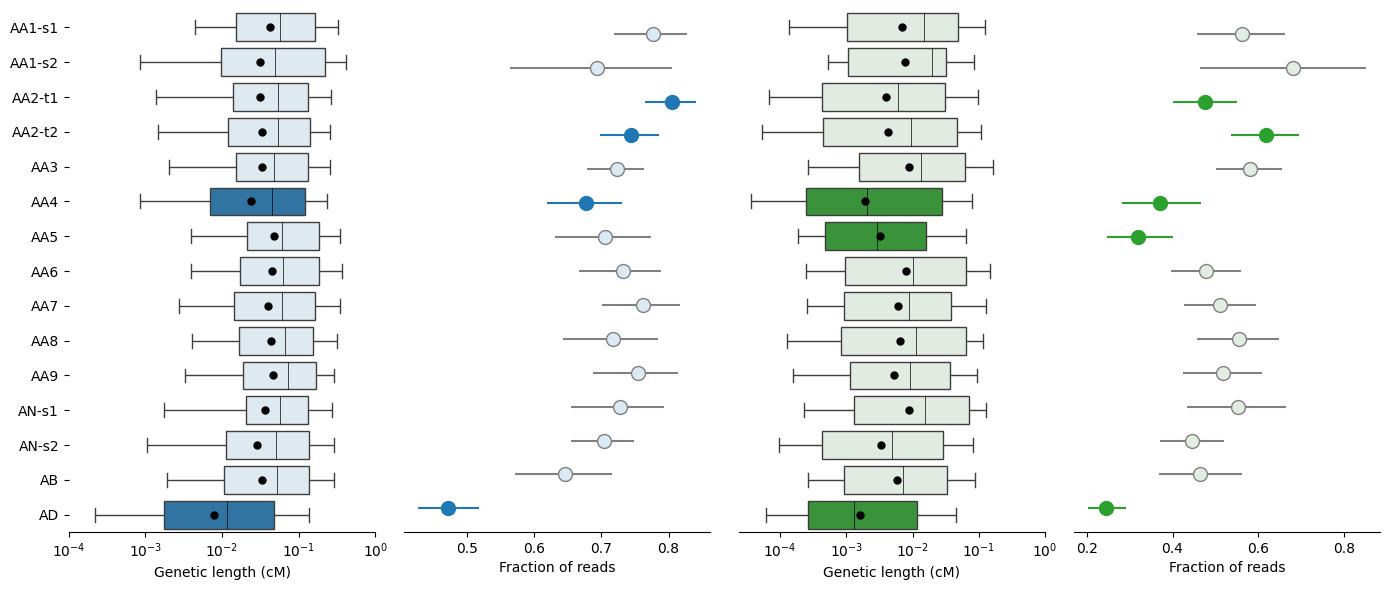

In [12]:
rows = []
for sample_id in tqdm.tqdm(sample_id_order):
    heats_CO = sample_id_to_AA_heats_co[sample_id]
    heats_NCO = sample_id_to_AA_heats_nco[sample_id]
    rows.append([
        sample_id,
        len(heats_CO),
        len(heats_NCO),
        (heats_CO == 0).sum(),
        (heats_NCO == 0).sum(),
    ])

AA_heats_co_vs_nco_df = pl.DataFrame(
    rows,
    schema=["sample_id", "n_CO", "n_NCO", "n_CO_zeros", "n_NCO_zeros"],
    orient="row",
)

rows = AA_heats_co_vs_nco_df.rows(named=True)
Drows = {row["sample_id"]: row for row in rows}

mns_co = [
    ((1 - Drows[s]["n_CO_zeros"] / Drows[s]["n_CO"]) if Drows[s]["n_CO"] else np.nan)
    for s in sample_presentation_order[:-1]
]
cis_co = [
    statsmodels.stats.proportion.proportion_confint(
        Drows[s]["n_CO"] - Drows[s]["n_CO_zeros"],
        Drows[s]["n_CO"],
        method="beta",
    )
    for s in sample_presentation_order[:-1]
]

mns_nco = [
    ((1 - Drows[s]["n_NCO_zeros"] / Drows[s]["n_NCO"]) if Drows[s]["n_NCO"] else np.nan)
    for s in sample_presentation_order[:-1]
]
cis_nco = [
    statsmodels.stats.proportion.proportion_confint(
        Drows[s]["n_NCO"] - Drows[s]["n_NCO_zeros"],
        Drows[s]["n_NCO"],
        method="beta",
    )
    for s in sample_presentation_order[:-1]
]

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(14, 6),
    width_ratios=[25, 25, 25, 25],
)

plot_boxplots_samples(
    CO_class_df.with_columns(cM=pl.col("CO_active_interval_crossover_prob") * 1e2),
    "cM",
    xlabel="Genetic length (cM)",
    take_log10=True,
    ticks=np.arange(-4, 1),
    label_to_color={
        "AD": CO_color,
        "AA4": CO_color,
    },
    default_color="#dbe9f3",
    ax=axs[0],
)

ax = axs[1]
for i in range(len(mns_co)):
    color = "grey"
    fill_color = "#dbe9f3"
    if sample_id_to_paper_label[sample_presentation_order[i]] in ["AD", "AA4", "AA2-t1", "AA2-t2"]:
        color = CO_color
        fill_color = CO_color
    ax.errorbar(
        y=i,
        x=mns_co[i],
        xerr=[[mns_co[i] - cis_co[i][0]], [cis_co[i][1] - mns_co[i]]],
        color=color,
        marker="o",
        mfc=fill_color,
        ms=10,
    )
ax.invert_yaxis()
ax.set_yticks([], [])
ax.set_xlabel("Fraction of reads")
ax.spines[["top", "right", "left"]].set_visible(False)

plot_boxplots_samples(
    NCO_df.with_columns(cM=pl.col("CO_active_interval_crossover_prob") * 1e2),
    "cM",
    xlabel="Genetic length (cM)",
    take_log10=True,
    ticks=np.arange(-4, 1),
    label_to_color={
        "AA5": NCO_color,
        "AA4": NCO_color,
        "AD": NCO_color,
    },
    show_labels=False,
    default_color="#e0ede0",
    ax=axs[2],
)

ax = axs[3]
for i in range(len(mns_co)):
    color = "grey"
    fill_color = "#e0ede0"
    if sample_id_to_paper_label[sample_presentation_order[i]] in ["AA4", "AA5", "AA2-t1", "AA2-t2", "AD"]:
        color = NCO_color
        fill_color = NCO_color
    ax.errorbar(
        y=i,
        x=mns_nco[i],
        xerr=[[mns_nco[i] - cis_nco[i][0]], [cis_nco[i][1] - mns_nco[i]]],
        color=color,
        marker="o",
        mfc=fill_color,
        ms=10,
    )
ax.invert_yaxis()
ax.set_yticks([], [])
ax.set_xlabel("Fraction of reads")
ax.spines[["top", "right", "left"]].set_visible(False)

fig.tight_layout()
fig.savefig(figure_dir / "individual_variation_co_nco.pdf")


## Sample comparisons

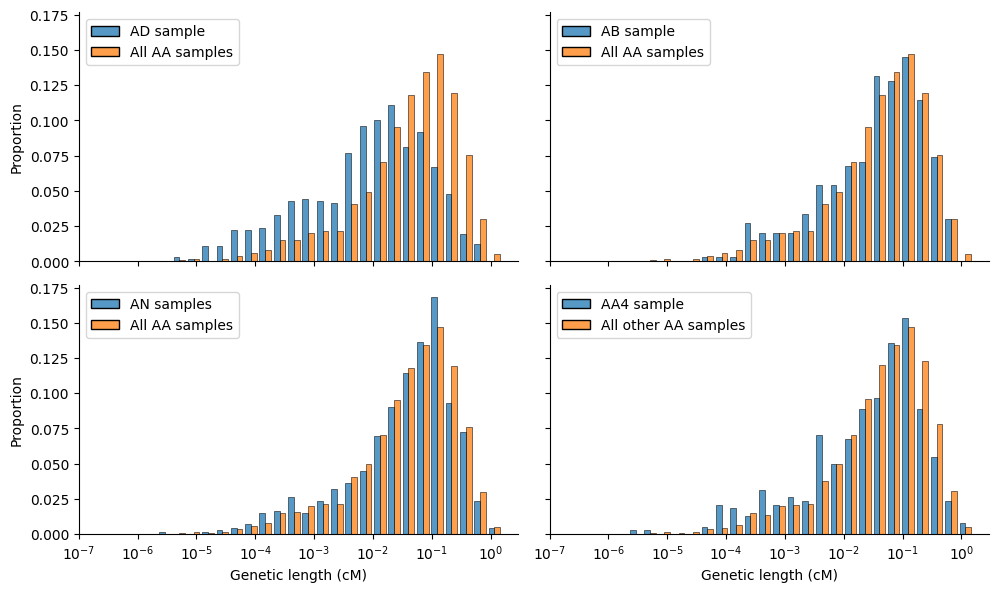

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

plot_cm_diffs(
    CO_class_df,
    ["AD"],
    [label for label in sample_id_to_paper_label.values() if "AA" in label],
    label_legend1="AD sample",
    label_legend2="All AA samples",
    ax=axs[0, 0],
)
plot_cm_diffs(
    CO_class_df,
    ["AB"],
    [label for label in sample_id_to_paper_label.values() if "AA" in label],
    label_legend1="AB sample",
    label_legend2="All AA samples",
    ax=axs[0, 1],
)
plot_cm_diffs(
    CO_class_df,
    ["AN-s1", "AN-s2"],
    [label for label in sample_id_to_paper_label.values() if "AA" in label],
    label_legend1="AN samples",
    label_legend2="All AA samples",
    ax=axs[1, 0],
)
plot_cm_diffs(
    CO_class_df,
    ["AA4"],
    [label for label in sample_id_to_paper_label.values() if "AA" in label and label not in ["AA4"]],
    label_legend1="AA4 sample",
    label_legend2="All other AA samples",
    ax=axs[1, 1],
)

plt.tight_layout()
fig.savefig(figure_dir / "co_genetic_length_sample_comparisons.pdf")


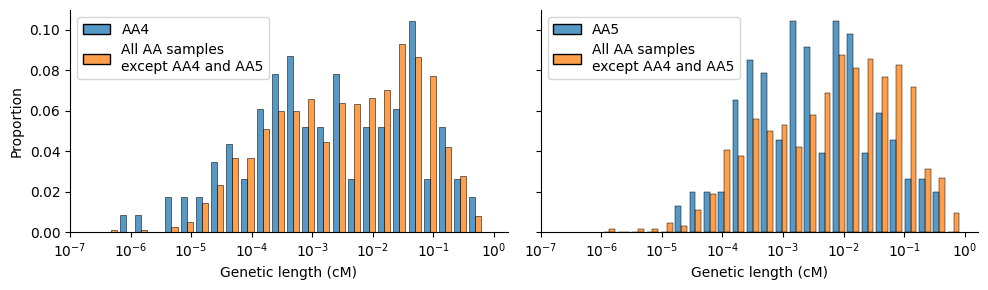

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharex=True, sharey=True)

plot_cm_diffs(
    NCO_df,
    ["AA4"],
    [label for sample_id, label in sample_id_to_paper_label.items() if sample_id in rahbari_sample_ids and label not in ["AA4", "AA5"]],
    label_legend1="AA4",
    label_legend2="All AA samples\nexcept AA4 and AA5",
    ax=axs[0],
)
plot_cm_diffs(
    NCO_df,
    ["AA5"],
    [label for sample_id, label in sample_id_to_paper_label.items() if sample_id in sudmant_sample_ids and label not in ["AA5", "AA4"]],
    label_legend1="AA5",
    label_legend2="All AA samples\nexcept AA4 and AA5",
    ax=axs[1],
)

plt.tight_layout()
fig.savefig(figure_dir / "nco_genetic_length_sample_comparisons.pdf")

## Tests

In [15]:
N_PERMS = 10000

co_genetic_aa = get_sample_vs_rest_tests(
    [s for s in sample_ids if sample_id_to_paper_label[s][:2] == "AA"],
    CO_class_df.filter(pl.col("CO_active_interval_crossover_prob").is_not_null()),
    "grch37_recombining_interval_cM",
    n_perms=N_PERMS,
)

co_genetic_aa_ad = get_sample_vs_rest_tests(
    [s for s in sample_ids if sample_id_to_paper_label[s][:2] in ["AA", "AD"] and sample_id_to_paper_label[s] != "AA4"],
    CO_class_df.filter(pl.col("CO_active_interval_crossover_prob").is_not_null()),
    "grch37_recombining_interval_cM",
    n_perms=N_PERMS,
)

co_genetic_aa_ab = get_sample_vs_rest_tests(
    [s for s in sample_ids if sample_id_to_paper_label[s][:2] in ["AA", "AB"] and sample_id_to_paper_label[s] != "AA4"],
    CO_class_df.filter(pl.col("CO_active_interval_crossover_prob").is_not_null()),
    "grch37_recombining_interval_cM",
    n_perms=N_PERMS,
)

co_dsb_fisher = test_fishers_exact_one_vs_rest(sample_ids, sample_id_to_AA_heats_co)
co_dsb_fisher_no_ad_twins = test_fishers_exact_one_vs_rest(
    [s for s in rahbari_sample_ids if sample_id_to_paper_label[s] not in ["AD", "AA2-t1", "AA1-s1"]],
    sample_id_to_AA_heats_co,
)

nco_genetic_aa_ad = get_sample_vs_rest_tests(
    [s for s in sample_ids if sample_id_to_paper_label[s][:2] in ["AA", "AD"] and sample_id_to_paper_label[s] != "AA4"],
    NCO_df.with_columns(cM=pl.col("CO_active_interval_crossover_prob") * 1e2),
    "cM",
    n_perms=N_PERMS,
)

nco_genetic_aa = get_sample_vs_rest_tests(
    [s for s in sample_ids if sample_id_to_paper_label[s][:2] == "AA"],
    NCO_df.with_columns(cM=pl.col("CO_active_interval_crossover_prob") * 1e2),
    "cM",
    n_perms=N_PERMS,
)


nco_dsb_signal_aa = get_sample_vs_rest_tests(
    [s for s in sample_ids if sample_id_to_paper_label[s][:2] == "AA"],
    NCO_df.with_columns(AA_heat_filled=pl.col("AA_heat").fill_null(0)),
    "AA_heat_filled",
    n_perms=N_PERMS,
)

nco_dsb_fisher = test_fishers_exact_one_vs_rest(sample_ids, sample_id_to_AA_heats_nco)

co_aa2_fisher = pairwise_fisher("PD46180c", "PD50519d", sample_id_to_AA_heats_co)
nco_aa2_fisher = pairwise_fisher("PD46180c", "PD50519d", sample_id_to_AA_heats_nco)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:   40.3s remaining:  3.0min
[Parallel(n_jobs=-1)]: Done   4 out of  11 | elapsed:   41.2s remaining:  1.2min
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:   42.5s remaining:   35.4s
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:   43.3s remaining:   16.2s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:   46.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:   41.5s remaining:  3.1min
[Parallel(n_jobs=-1)]: Done   4 out of  11 | elapsed:   41.6s remaining:  1.2min
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:   42.9s remaining:   35.8s
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:   45.4s remaining:   17.0s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:   48.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:   

## Summary

In [16]:
def by_label(df, label, column):
    return df.filter(pl.col("paper_label_id") == label)[column].item(0)

def fisher_by_label(df, label):
    return df.filter(pl.col("paper_label") == label)["fisher_pval"].item(0)

key_values = {
    "AD CO genetic length AD permutation P": by_label(co_genetic_aa_ad, "AD", "AD_perm_pvalue"),
    "AB CO genetic length AD permutation P": by_label(co_genetic_aa_ab, "AB", "AD_perm_pvalue"),
    "AA4 CO genetic length AD permutation P": by_label(co_genetic_aa, "AA4", "AD_perm_pvalue"),
    "AD CO DSB Fisher P": fisher_by_label(co_dsb_fisher, "AD"),
    "AD NCO genetic length AD permutation P": by_label(nco_genetic_aa_ad, "AD", "AD_perm_pvalue"),
    "AA4 NCO genetic length AD permutation P": by_label(nco_genetic_aa, "AA4", "AD_perm_pvalue"),
    "AA5 NCO genetic length AD permutation P": by_label(nco_genetic_aa, "AA5", "AD_perm_pvalue"),
    "AA4 NCO DSB signal AD permutation P": by_label(nco_dsb_signal_aa, "AA4", "AD_perm_pvalue"),
    "AA5 NCO DSB signal AD permutation P": by_label(nco_dsb_signal_aa, "AA5", "AD_perm_pvalue"),
    "AA2 twin CO DSB Fisher P": co_aa2_fisher,
    "AA2 twin NCO DSB Fisher P": nco_aa2_fisher,
}

key_values


{'AD CO genetic length AD permutation P': 0.0,
 'AB CO genetic length AD permutation P': 0.0,
 'AA4 CO genetic length AD permutation P': 0.0,
 'AD CO DSB Fisher P': 7.019940307627527e-29,
 'AD NCO genetic length AD permutation P': 0.0,
 'AA4 NCO genetic length AD permutation P': 0.0,
 'AA5 NCO genetic length AD permutation P': 0.0,
 'AA4 NCO DSB signal AD permutation P': 0.0,
 'AA5 NCO DSB signal AD permutation P': 0.0,
 'AA2 twin CO DSB Fisher P': np.float64(0.03862771752346153),
 'AA2 twin NCO DSB Fisher P': np.float64(0.01156654892830103)}